## 02_preprocess_compare.ipynb

- Обработка и очистка датасета
- Извлечение новых признаков
- Работа с категориальными признаками
- Сравнение моделей машинного обучения
- Выбор лучших гиперпараметров для более успешной модели

In [97]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

In [98]:
root_dir = Path.cwd().parent
print(root_dir)
sys.path.insert(0, str(root_dir))

c:\Users\chise\Desktop\aie_dop\aie_chistyakova\project


In [99]:
from src.utils.configs import load_configs

configs = load_configs()
raw_data_path = configs["data"]["raw_path"]
data_path = root_dir / raw_data_path

df_raw = pd.read_csv(data_path)

In [100]:
features = configs['features']
target = configs['data']['target_column']

In [101]:
df = df_raw.copy()
df = df[df['duration'] <= 30]

In [102]:
df["stops"] = df["stops"].replace({'zero' : 0,'one' : 1,'two_or_more' : 2}).astype(int)
df["class"] = df["class"].replace({'Economy' : 0,'Business' : 1}).astype(int)
    
dummies_variables = ["airline","source_city","destination_city","departure_time","arrival_time"]
dummies = pd.get_dummies(df[dummies_variables], drop_first = True)
df = pd.concat([df,dummies], axis=1)
    
df = df.drop(["Unnamed: 0", "flight","airline","source_city","destination_city","departure_time","arrival_time"] ,axis=1)

In [103]:
df['price_per_hour'] = df['price'] / df['duration']

In [104]:
df.info()

<class 'pandas.DataFrame'>
Index: 297927 entries, 0 to 300152
Data columns (total 31 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   stops                         297927 non-null  int64  
 1   class                         297927 non-null  int64  
 2   duration                      297927 non-null  float64
 3   days_left                     297927 non-null  int64  
 4   price                         297927 non-null  int64  
 5   airline_Air_India             297927 non-null  bool   
 6   airline_GO_FIRST              297927 non-null  bool   
 7   airline_Indigo                297927 non-null  bool   
 8   airline_SpiceJet              297927 non-null  bool   
 9   airline_Vistara               297927 non-null  bool   
 10  source_city_Chennai           297927 non-null  bool   
 11  source_city_Delhi             297927 non-null  bool   
 12  source_city_Hyderabad         297927 non-null  bool   
 13  

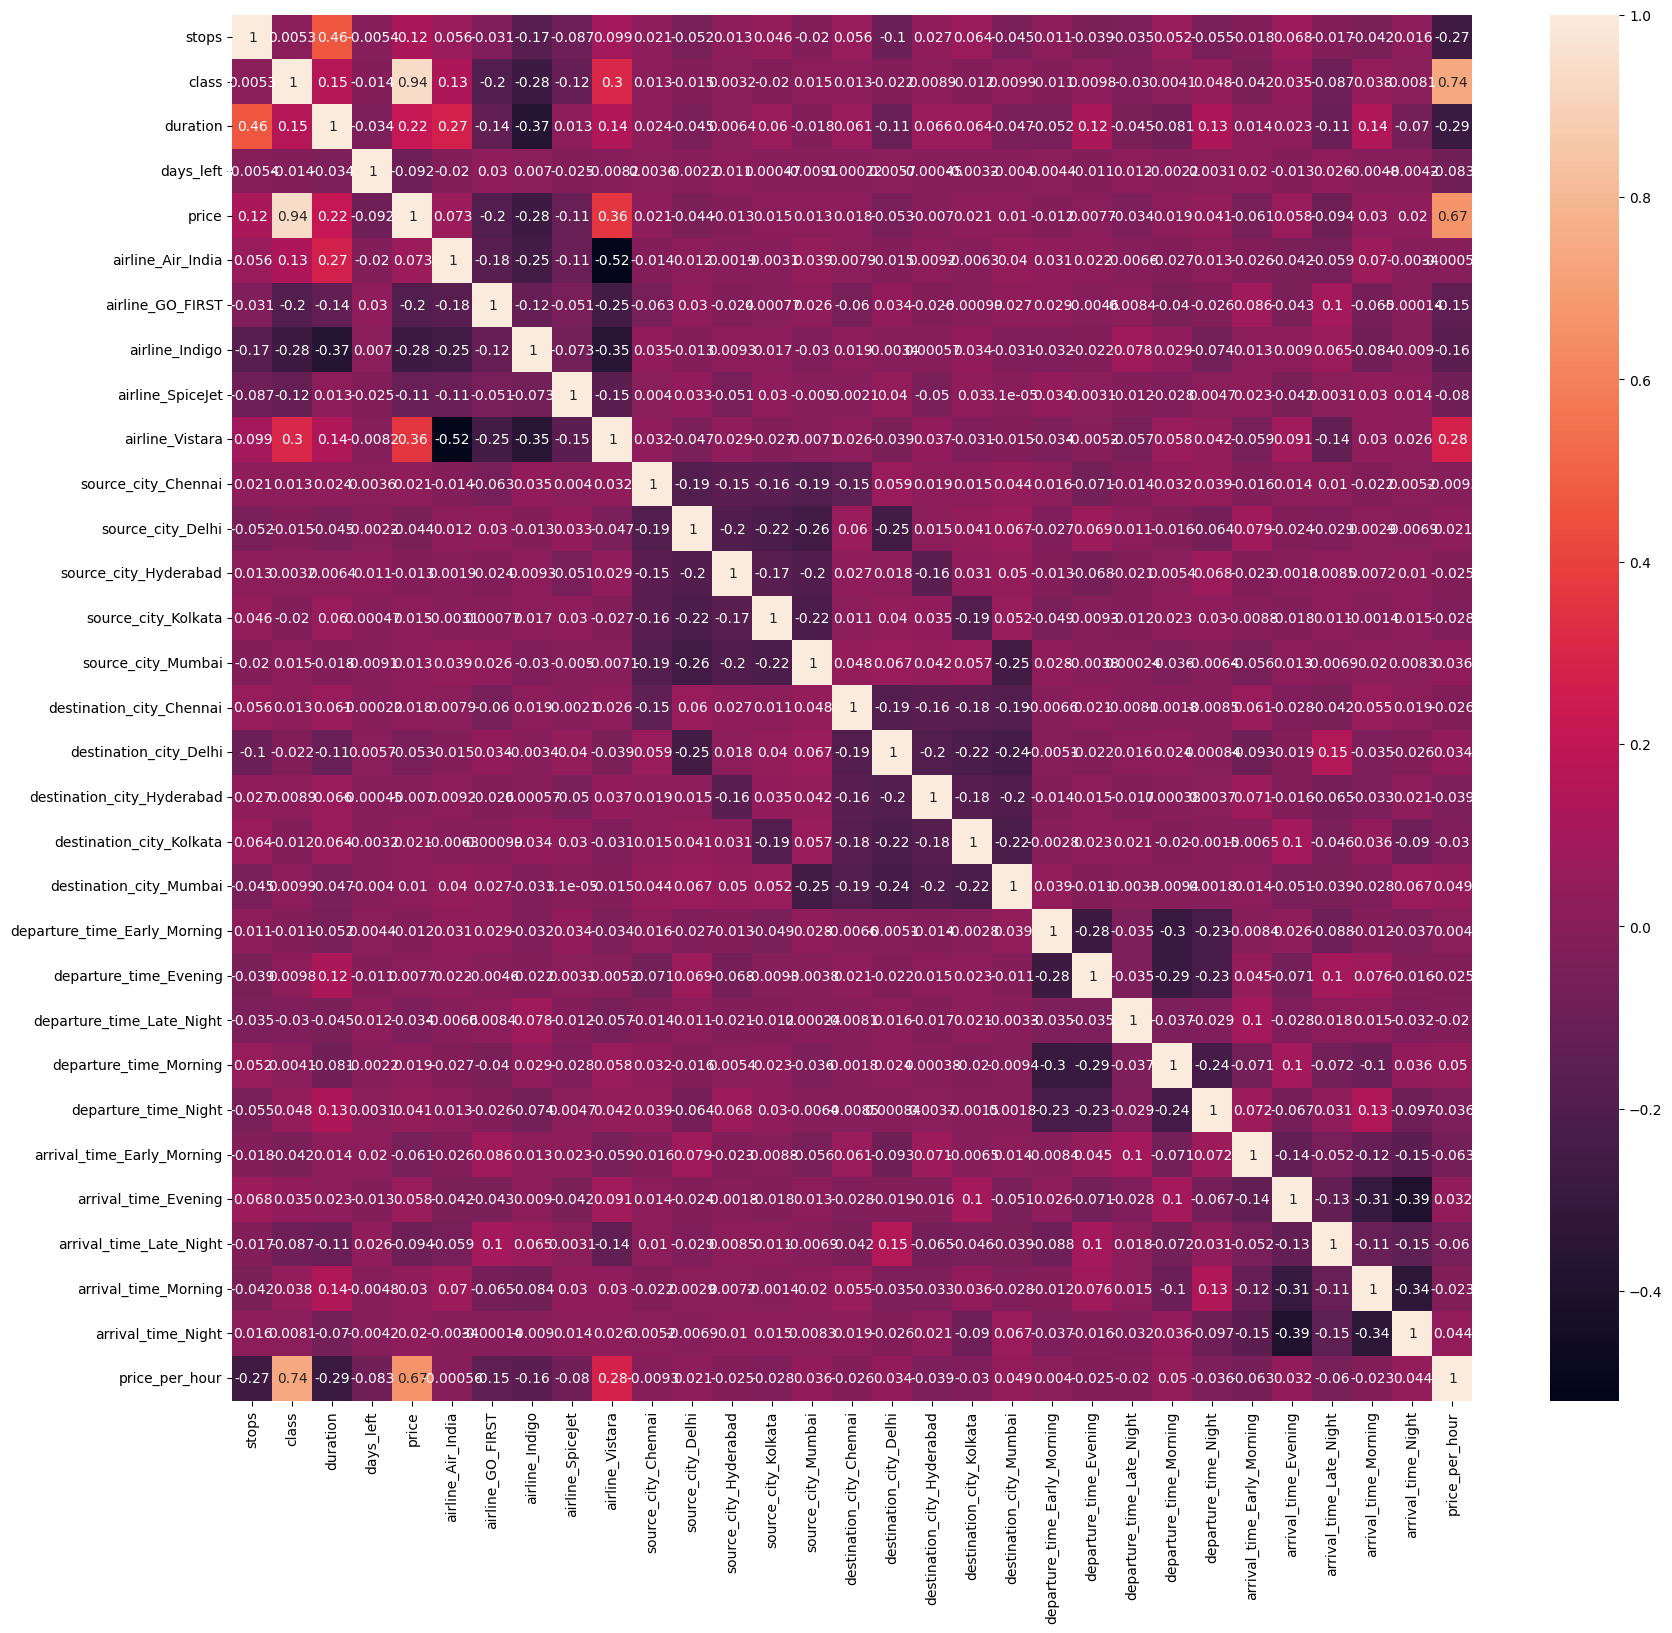

In [112]:
path_corr = root_dir / configs['artifacts']['plots']['correlation_matrix']
plt.figure(figsize = (20,18))
corr = df.corr()
sns.heatmap(df.corr(), annot = True)
plt.savefig(path_corr)

In [105]:
X = df[features]
y = df[target]

In [106]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 42, test_size=0.15, shuffle=True)

In [107]:
def score(y_test, y_pred, y_prob=None):
    metrics = {
        'MAE':   round(mean_absolute_error(y_test, y_pred), 4),
        'MSE':   round(mean_squared_error(y_test, y_pred), 4),
        'RMSE':  round(root_mean_squared_error(y_test, y_pred), 4),
        'R2':    round(r2_score(y_test, y_pred), 4),
    }
    
    return metrics

In [108]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

lin_reg_pred = lin_reg.predict(X_test)

lin_reg_metrics = score(y_test, lin_reg_pred)

In [109]:
xgb_reg = XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42)
xgb_reg.fit(X_train, y_train)
xgb_reg_pred = xgb_reg.predict(X_test)
xgb_reg_metrics = score(y_test, xgb_reg_pred)

In [110]:
cat_reg = CatBoostRegressor(iterations=100, depth=6, learning_rate=0.1, random_seed=42, verbose=False)
cat_reg.fit(X_train, y_train)
cat_reg_pred = cat_reg.predict(X_test)
cat_reg_metrics = score(y_test, cat_reg_pred)

In [111]:
path_comp = root_dir / configs['artifacts']['metrics']['metrics_compare']
comparison = pd.DataFrame({
    'Linear_Regression': lin_reg_metrics,
    'XGBoost': xgb_reg_metrics,
    'CatBoost': cat_reg_metrics
})

print(comparison)
comparison.to_csv(path_comp)

      Linear_Regression      XGBoost      CatBoost
MAE        4.515763e+03     311.6251  8.467105e+02
MSE        4.625425e+07  352577.4375  1.855345e+06
RMSE       6.801047e+03     593.7823  1.362111e+03
R2         9.102000e-01       0.9993  9.964000e-01


In [95]:
xgb_params_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.3]
}

xgb_grid = GridSearchCV(
    estimator=XGBRegressor(
        random_state=42
    ),
    param_grid=xgb_params_grid,
    cv=5,
    scoring='r2',
    verbose=1
)

xgb_grid.fit(X_train, y_train)

print('Лучшие параметры')
print(xgb_grid.best_params_)

best_xgb_reg = xgb_grid.best_estimator_
xgb_reg_pred = best_xgb_reg.predict(X_test)
xgb_reg_metrics = score(y_test, xgb_reg_pred)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Лучшие параметры
{'learning_rate': 0.05, 'max_depth': 9, 'n_estimators': 200}


In [96]:
xgb_reg_metrics

{'MAE': 128.3053, 'MSE': 157182.1875, 'RMSE': 396.4621, 'R2': 0.9997}